# 🧬 Near-Duplicate Finder for a RAG Corpus

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/embedding-dedup/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/embedding-dedup/demo.ipynb)

**A duplicate in a vector index does not cost you storage. It costs you the answer.**

Retrieval returns the top *k* chunks. If three of those five slots hold the same policy
paragraph re-exported from three systems, the model sees one document three times and
never sees the two documents that got pushed out. You pay for the tokens, and you get a
worse answer than an empty index would have forced you to notice.

The obvious fix - cosine similarity above some threshold, merge - is wrong in both
directions, and this notebook shows exactly where:

| Failure | What cosine does | What fixes it |
|---|---|---|
| Two quarterly reports off one template | merges them (0.81) - **deletes a filing** | numeric fingerprint veto |
| A paragraph absorbed into a longer FAQ | misses it (0.58) | containment |
| Nav footers similar to everything | merges unrelated pages | minimum-length hold-out |

### What this notebook covers
1. Why cosine alone conflates *same document* with *same topic*
2. The three signals, and the one each of them alone gets wrong
3. Rare-token blocking - not scoring 500M pairs at 30k documents
4. A labelled corpus: F1 goes **0.80 → 0.91 → 1.00** as each signal is added
5. The retrieval result page before and after dedup
6. Your own corpus, at the bottom

No API key, no network, no model call. TF-IDF vectors stand in for embeddings; the gate
is the transferable part, and it accepts a real embedding matrix unchanged.

## 1. The corpus

Fourteen documents from a support and finance knowledge base, containing the four things
every real index contains: the same page exported three ways, an edited fork, a paragraph
swallowed by a longer page, and **template siblings that must not be merged**.

The `dup_group` column is the ground truth - it exists so we can measure false merges
rather than eyeball the clusters and declare victory.

In [1]:
from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Set, Tuple

import numpy as np
import pandas as pd

from dedup import SAMPLE_DOCS, TfidfIndex, containment, numbers_in, tokenize

docs = SAMPLE_DOCS
index = TfidfIndex([d["text"] for d in docs])

pd.DataFrame([{
    "#": i,
    "id": d["id"],
    "source": d["source"],
    "truth group": d["dup_group"] or "-",
    "tokens": len(index.token_lists[i]),
    "numbers": len(numbers_in(d["text"])),
    "text": d["text"][:64] + "...",
} for i, d in enumerate(docs)])

,#,id,source,truth group,tokens,numbers,text
0,0,kb-refund-policy,helpdesk,A,42,2,Refund policy. Customers may request a full re...
1,1,web-refunds-page,website,A,42,2,**REFUND POLICY. CUSTOMERS MAY REQUEST A FUL...
2,2,pdf-refunds-v3,pdf-export,A,44,3,**Refund Policy**\n Customers may request a fu...
3,3,kb-onboarding-2024,helpdesk,B,35,1,Customer onboarding checklist. Create the work...
4,4,kb-onboarding-2025-draft,notion,B,41,2,Customer onboarding checklist (2025 revision)....
5,5,kb-sla-shipping,helpdesk,C,20,1,Standard fulfilment is dispatched within two b...
6,6,web-shipping-faq,website,C,54,1,Shipping FAQ. Where is my order? Tracking appe...
7,7,fin-q1-summary,finance,-,40,7,Quarterly revenue summary. Net revenue for the...
8,8,fin-q2-summary,finance,-,39,7,Quarterly revenue summary. Net revenue for the...
9,9,nav-footer-a,website,-,6,0,"See also: pricing, security, status page...."


## 2. Where cosine similarity fails

Two pairs, both scored by cosine on the same TF-IDF vectors. One is a genuine duplicate,
one is two different financial filings. Cosine cannot tell them apart, and it ranks them
in the *wrong order*.

This is not a threshold-tuning problem. There is no cutoff that keeps the duplicate and
rejects the filings, because cosine measures shared vocabulary and both pairs share their
vocabulary. The signal that separates them is not in the prose.

In [2]:
def cos(a: int, b: int) -> float:
    return float(index.vectors[a] @ index.vectors[b])

pairs_to_examine = [
    (5, 6, "TRUE duplicate: paragraph absorbed into the shipping FAQ"),
    (7, 8, "NOT duplicates: Q1 and Q2 filings off one template"),
]

for a, b, label in pairs_to_examine:
    print(f"{label}")
    print(f"  {docs[a]['id']:<18} ~ {docs[b]['id']:<18} cosine = {cos(a, b):.3f}")

print("\nRanked by cosine, the pair we must NOT merge scores HIGHER")
print(f"  than the pair we must merge: {cos(7, 8):.3f} > {cos(5, 6):.3f}")
print("\nA single threshold has no correct value here. It gets one of the two wrong.")

TRUE duplicate: paragraph absorbed into the shipping FAQ
  kb-sla-shipping    ~ web-shipping-faq   cosine = 0.575
NOT duplicates: Q1 and Q2 filings off one template
  fin-q1-summary     ~ fin-q2-summary     cosine = 0.810

Ranked by cosine, the pair we must NOT merge scores HIGHER
  than the pair we must merge: 0.810 > 0.575

A single threshold has no correct value here. It gets one of the two wrong.


## 3. Signal two: containment

Cosine punishes a length mismatch. A 20-token paragraph copied verbatim into a 54-token
FAQ page scores 0.58, because two thirds of the longer document is material the shorter
one never had - and cosine reads that absence as difference.

Containment asks a different question: **is one document's vocabulary a subset of the
other's?** `|A ∩ B| / min(|A|, |B|)`, over discriminative tokens only, so shared
stopwords and corpus-wide boilerplate cannot inflate it.

For the absorbed paragraph, containment is **1.000** - every rare token in the short
document appears in the long one. That is what "already in the index" actually means.

In [3]:
rare = [index.rare_tokens(i) for i in range(len(docs))]

for a, b, label in pairs_to_examine:
    print(f"{label}")
    print(f"  cosine      = {cos(a, b):.3f}")
    print(f"  containment = {containment(rare[a], rare[b]):.3f}")
    print()

print("Containment rescues the absorbed paragraph (0.58 cosine -> 1.00 containment).")
print("It does NOT solve the filings: same template = same vocabulary = 0.81 either way.")

TRUE duplicate: paragraph absorbed into the shipping FAQ
  cosine      = 0.575
  containment = 1.000

NOT duplicates: Q1 and Q2 filings off one template
  cosine      = 0.810
  containment = 0.806

Containment rescues the absorbed paragraph (0.58 cosine -> 1.00 containment).
It does NOT solve the filings: same template = same vocabulary = 0.81 either way.


## 4. Signal three: the numeric fingerprint

The two filings differ in exactly the part that matters and nowhere else. Every sentence
of prose is shared; every *figure* disagrees. So stop reading the prose and compare the
claims:

> **numeric fingerprint** — the set of numbers a document asserts. If two documents both
> make several numeric claims and those claims disagree, they are not the same document,
> however similar the sentences around them read.

This is a veto, not a score: it can only *block* a merge, never cause one. Documents with
fewer than two numbers return `None` - not enough evidence to judge, so the veto abstains
rather than guessing. For the refund policy pair the numbers agree perfectly (1.00) and
the veto stays out of the way.

In [4]:
from dedup import numeric_agreement

for a, b in [(0, 2), (5, 6), (7, 8)]:
    na, nb = numbers_in(docs[a]["text"]), numbers_in(docs[b]["text"])
    agree = numeric_agreement(na, nb)
    verdict = "abstains (too few numbers)" if agree is None else (
        "VETO - figures disagree" if agree < 0.5 else "no objection")
    print(f"{docs[a]['id']:<18} ~ {docs[b]['id']:<18}")
    print(f"   A: {sorted(na) or 'none'}")
    print(f"   B: {sorted(nb) or 'none'}")
    print(f"   agreement = {'n/a' if agree is None else f'{agree:.2f}'}  ->  {verdict}\n")

kb-refund-policy   ~ pdf-refunds-v3    
   A: ['30', '5']
   B: ['30', '4', '5']
   agreement = 0.67  ->  no objection

kb-sla-shipping    ~ web-shipping-faq  
   A: ['1400']
   B: ['1400']
   agreement = n/a  ->  abstains (too few numbers)

fin-q1-summary     ~ fin-q2-summary    
   A: ['108', '12', '1310000', '27', '402000', '4820000', '71']
   B: ['111', '1455000', '28', '5140000', '517000', '69', '9']
   agreement = 0.00  ->  VETO - figures disagree



## 5. Blocking: why this does not melt at scale

All-pairs cosine is quadratic. Fourteen documents is 91 comparisons - fine. Thirty
thousand documents is **450 million**, and that is before you multiply by embedding
dimensionality.

Two documents with no discriminative token in common cannot clear a 0.8 cosine bar, so
they never need scoring. Build an inverted index over tokens appearing in at most half
the corpus, then only compare documents that share a posting list. On this corpus that
skips 57% of the work; the saving grows with corpus size, because a rare token's posting
list stays short as the corpus grows.

In [5]:
from dedup import candidate_pairs, find_duplicates

cands = candidate_pairs(index)
n = len(docs)
all_pairs = n * (n - 1) // 2
print(f"documents:        {n}")
print(f"all pairs:        {all_pairs}")
print(f"candidate pairs:  {len(cands)}  ({100 - 100*len(cands)/all_pairs:.0f}% skipped)")

# Where the quadratic term actually bites.
print("\nall-pairs comparisons at scale:")
for size in (1_000, 10_000, 100_000):
    print(f"  {size:>7,} docs -> {size*(size-1)//2:>15,} pairs")

documents:        14
all pairs:        91
candidate pairs:  39  (57% skipped)

all-pairs comparisons at scale:
    1,000 docs ->         499,500 pairs
   10,000 docs ->      49,995,000 pairs
  100,000 docs ->   4,999,950,000 pairs


## 6. The full gate

Two ways to link, because cosine and containment answer different questions:

- **`near`** — `cosine ≥ 0.80` **and** `containment ≥ 0.65` → two versions of one document
- **`subset`** — `containment ≥ 0.90` at *any* cosine → one document absorbed into another

Either link can be vetoed by disagreeing numeric fingerprints. Exact matches after
normalisation skip scoring entirely (hash first, it is free). Links are then closed
transitively with union-find, and the **longest** member survives each cluster - a superset
keeps the detail a shorter copy dropped.

Every rejected pair is reported with its reason. A dedup pass that silently deletes
documents is unauditable, and the rejected list is where you find out your index is full
of template siblings.

In [6]:
result = find_duplicates(docs)
kind_of = {(p["a"], p["b"]): p.get("kind", "near") for p in result["pairs"]}

print("CLUSTERS\n")
for c in result["clusters"]:
    via = sorted({k for (a, b), k in kind_of.items()
                  if a in c["members"] and b in c["members"]})
    print(f"  keep  {docs[c['keep']]['id']:<26} (via {'+'.join(via)})")
    for i in c["drop"]:
        print(f"  drop  {docs[i]['id']:<26} [{docs[i]['source']}]")
    print()

print("REJECTED - similar enough to consider, gate said no\n")
for r in result["rejected"]:
    print(f"  {docs[r['a']]['id']:<18} ~ {docs[r['b']]['id']:<18} "
          f"cos={r['cosine']:.2f} con={r['containment']:.2f}")
    for reason in r["reasons"]:
        print(f"      -> {reason}")

print("\nHELD OUT - fragments too short for any signal to mean anything\n")
for i in result["fragments"]:
    print(f"  {docs[i]['id']:<18} {docs[i]['text']!r}")

CLUSTERS

  keep  pdf-refunds-v3             (via exact+near)
  drop  kb-refund-policy           [helpdesk]
  drop  web-refunds-page           [website]

  keep  kb-onboarding-2025-draft   (via near)
  drop  kb-onboarding-2024         [helpdesk]

  keep  web-shipping-faq           (via subset)
  drop  kb-sla-shipping            [helpdesk]

REJECTED - similar enough to consider, gate said no

  fin-q1-summary     ~ fin-q2-summary     cos=0.81 con=0.81
      -> numeric fingerprints disagree (0.00 < 0.50)

HELD OUT - fragments too short for any signal to mean anything

  nav-footer-a       'See also: pricing, security, status page.'
  nav-footer-b       'See also: pricing, careers, status page.'


## 7. Does it actually work? Ablation against the labels

Clusters that look right are not evidence. The corpus is labelled, so score pair-level
precision and recall while switching each signal on.

**Precision matters more than recall here, and it is not close.** A missed duplicate
wastes a fraction of a cent of storage. A false merge deletes a document that no longer
exists anywhere in the index - you cannot recover Q1 from Q2.

In [7]:
from dedup import cluster_pairs, evaluate, truth_pairs

truth = truth_pairs(docs)
ablations = [
    ("cosine only", dict(contain_threshold=0.0, subset_threshold=1.01, numeric_threshold=0.0)),
    ("+ containment", dict(numeric_threshold=0.0)),
    ("+ numeric veto", dict()),
]

rows = []
for name, kwargs in ablations:
    res = find_duplicates(docs, **kwargs)
    m = evaluate(cluster_pairs(res), truth)
    rows.append({"gate": name, "precision": m["precision"], "recall": m["recall"],
                 "F1": m["f1"], "false merges": m["fp"], "missed": m["fn"]})
    for a, b in m["false_merges"]:
        print(f"  [{name}] FALSE MERGE: {docs[a]['id']} + {docs[b]['id']}")
    for a, b in m["missed"]:
        print(f"  [{name}] missed:      {docs[a]['id']} + {docs[b]['id']}")

ablation_df = pd.DataFrame(rows)
ablation_df

  [cosine only] FALSE MERGE: fin-q1-summary + fin-q2-summary
  [cosine only] missed:      kb-sla-shipping + web-shipping-faq
  [+ containment] FALSE MERGE: fin-q1-summary + fin-q2-summary


,gate,precision,recall,F1,false merges,missed
0,cosine only,0.800,0.8,0.800,1,1
1,+ containment,0.833,1.0,0.909,1,0
2,+ numeric veto,1.000,1.0,1.000,0,0


## 8. The picture

Left: every candidate pair in cosine × containment space, with the accept regions shaded.
Note what is sitting *inside* the shaded boxes and should not be there:

- the two **filings** (red X) clear both bars - only the numeric veto keeps them out
- the two **nav footers** (grey square) also clear both bars, and no similarity signal
  can help, because at six tokens they genuinely *are* nearly the same string. Only the
  minimum-length hold-out stops them
- the **absorbed paragraph** (green, at containment 1.00) sits far below any usable cosine
  bar and is caught by the subset rule alone

Three interventions, three different failure modes. That is why this is a gate and not a
threshold.

Right: what each signal buys, in F1.

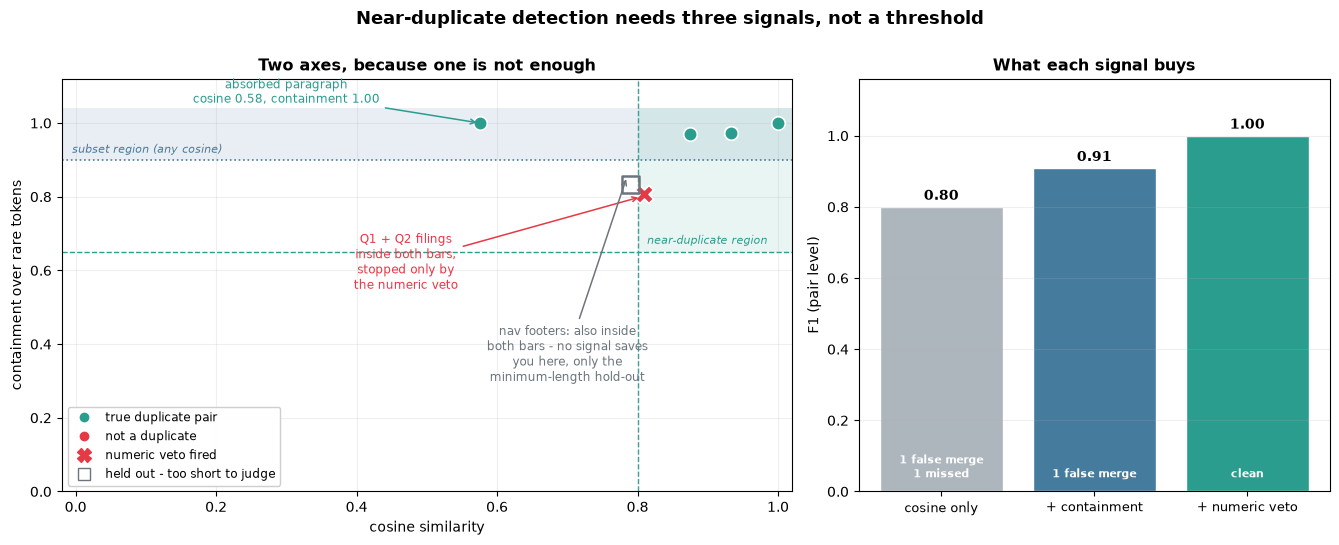

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

COS_T, CON_T, SUB_T = 0.80, 0.65, 0.90
truth_set = {tuple(sorted(p)) for p in truth}

scored = []
for a, b in sorted(cands):
    c, k = cos(a, b), containment(rare[a], rare[b])
    if c < 0.35 and k < SUB_T:
        continue
    scored.append((a, b, c, k, tuple(sorted((a, b))) in truth_set))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4),
                              gridspec_kw={"width_ratios": [1.55, 1]})

ax.add_patch(Rectangle((COS_T, CON_T), 1.02 - COS_T, 1.04 - CON_T,
                       facecolor="#2a9d8f", alpha=0.10, zorder=0))
ax.add_patch(Rectangle((-0.02, SUB_T), 1.04, 1.04 - SUB_T,
                       facecolor="#457b9d", alpha=0.12, zorder=0))
ax.axvline(COS_T, color="#2a9d8f", ls="--", lw=1, zorder=1)
ax.axhline(CON_T, color="#2a9d8f", ls="--", lw=1, zorder=1)
ax.axhline(SUB_T, color="#457b9d", ls=":", lw=1.2, zorder=1)

frag = set(result["fragments"])
for a, b, c, k, is_dup in scored:
    veto = (lambda v: v is not None and v < 0.5)(
        numeric_agreement(numbers_in(docs[a]["text"]), numbers_in(docs[b]["text"])))
    if a in frag or b in frag:          # held out on length, before any signal ran
        ax.scatter(c, k, s=150, facecolor="none", edgecolor="#6c757d",
                   linewidth=1.8, marker="s", zorder=3)
    else:
        ax.scatter(c, k, s=170 if veto else 95,
                   color="#2a9d8f" if is_dup else "#e63946",
                   marker="X" if veto else "o",
                   edgecolor="white", linewidth=1.2, zorder=3)

ax.annotate("Q1 + Q2 filings\ninside both bars,\nstopped only by\nthe numeric veto",
            xy=(0.805, 0.80), xytext=(0.47, 0.55), fontsize=8.5, color="#e63946",
            ha="center", arrowprops=dict(arrowstyle="->", color="#e63946", lw=1.1))
ax.annotate("absorbed paragraph\ncosine 0.58, containment 1.00",
            xy=(0.575, 1.0), xytext=(0.30, 1.055), fontsize=8.5, color="#2a9d8f",
            ha="center", arrowprops=dict(arrowstyle="->", color="#2a9d8f", lw=1.1))
ax.annotate("nav footers: also inside\nboth bars - no signal saves\nyou here, only the\nminimum-length hold-out",
            xy=(0.785, 0.855), xytext=(0.70, 0.30), fontsize=8.5, color="#6c757d",
            ha="center", arrowprops=dict(arrowstyle="->", color="#6c757d", lw=1.1))

ax.text(0.985, CON_T + 0.015, "near-duplicate region", fontsize=8, color="#2a9d8f",
        ha="right", va="bottom", style="italic")
ax.text(-0.005, SUB_T + 0.012, "subset region (any cosine)", fontsize=8, color="#457b9d",
        ha="left", va="bottom", style="italic")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("containment over rare tokens")
ax.set_title("Two axes, because one is not enough", fontsize=11.5, fontweight="bold")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.0, 1.12)
ax.grid(alpha=0.2)
handles = [
    plt.Line2D([], [], marker="o", ls="", color="#2a9d8f", label="true duplicate pair"),
    plt.Line2D([], [], marker="o", ls="", color="#e63946", label="not a duplicate"),
    plt.Line2D([], [], marker="X", ls="", color="#e63946", markersize=10,
               label="numeric veto fired"),
    plt.Line2D([], [], marker="s", ls="", markerfacecolor="none", markeredgecolor="#6c757d",
               markersize=9, label="held out - too short to judge"),
]
ax.legend(handles=handles, fontsize=8.5, loc="lower left", framealpha=0.95)

bars = ax2.bar(ablation_df["gate"], ablation_df["F1"],
               color=["#adb5bd", "#457b9d", "#2a9d8f"], edgecolor="white")
for bar, (_, row) in zip(bars, ablation_df.iterrows()):
    ax2.text(bar.get_x() + bar.get_width() / 2, row["F1"] + 0.02, f"{row['F1']:.2f}",
             ha="center", fontsize=10, fontweight="bold")
    note = []
    if row["false merges"]:
        note.append(f"{int(row['false merges'])} false merge")
    if row["missed"]:
        note.append(f"{int(row['missed'])} missed")
    ax2.text(bar.get_x() + bar.get_width() / 2, 0.04, "\n".join(note) or "clean",
             ha="center", fontsize=8, color="white", fontweight="bold")
ax2.set_ylim(0, 1.16)
ax2.set_ylabel("F1 (pair level)")
ax2.set_title("What each signal buys", fontsize=11.5, fontweight="bold")
ax2.tick_params(axis="x", labelsize=9)
ax2.grid(axis="y", alpha=0.2)

fig.suptitle("Near-duplicate detection needs three signals, not a threshold",
             fontsize=13, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig("dedup_signals.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. What it is worth: the result page

The savings line everyone quotes is embedding spend, and on this corpus it is
**four thousandths of a cent**. That is not the argument.

The argument is the result page. Ask the index a refund question and the entire top-3 is
one document, restated three times. The generator pays for three copies of one claim and
never sees the shipping policy that would have completed the answer. After dedup the same
three slots carry two distinct answers.

Duplicates do not make retrieval expensive. They make it **narrow**.

In [9]:
from dedup import dedup_plan, distinct_answers, redundant_slots, retrieve

plan = dedup_plan(docs, result)
dropped = {d["index"] for d in plan["dropped"]}

query = "how many business days for a refund to reach the original payment method"
before = retrieve(result["index"], query, k=3)
after = retrieve(result["index"], query, k=3, exclude=dropped)

print(f"query: {query!r}\n")
for title, hits in (("BEFORE dedup", before), ("AFTER dedup", after)):
    print(f"{title}: {distinct_answers(result, hits)} distinct answers, "
          f"{redundant_slots(result, hits)} redundant slots")
    for i, s in hits:
        print(f"   {s:.3f}  {docs[i]['id']:<20} [{docs[i]['source']}]")
    print()

print(f"index: keep {plan['keep_count']} of {result['n_docs']} documents, "
      f"{plan['tokens_saved']:,} of {plan['total_tokens']:,} tokens dropped "
      f"({plan['pct_index_saved']}%)")
print(f"re-embedding saved: ${plan['embedding_cost_saved']:.6f} - the small number.")
print("the large number is the answer that was missing from the top-3.")

query: 'how many business days for a refund to reach the original payment method'

BEFORE dedup: 1 distinct answers, 2 redundant slots
   0.415  kb-refund-policy     [helpdesk]
   0.415  web-refunds-page     [website]
   0.399  pdf-refunds-v3       [pdf-export]

AFTER dedup: 2 distinct answers, 0 redundant slots
   0.399  pdf-refunds-v3       [pdf-export]
   0.102  web-shipping-faq     [website]

index: keep 10 of 14 documents, 319 of 1,018 tokens dropped (31.3%)
re-embedding saved: $0.000041 - the small number.
the large number is the answer that was missing from the top-3.


## 10. Try your own corpus

Uncomment, paste your own documents, and read the **rejected** list first - it is more
informative than the clusters. If your rejected list is full of numeric vetoes, your
index is full of templated reports, and a plain cosine dedup would have been quietly
deleting them.

To use real embeddings instead of TF-IDF, pass the matrix straight in: `vectors=` takes
any `(n_docs, dim)` array and is L2-normalised for you. The gate does not change.

In [10]:
# MY_DOCS = [
#     {"id": "doc-1", "source": "confluence", "text": "..."},
#     {"id": "doc-2", "source": "notion",     "text": "..."},
# ]
#
# res = find_duplicates(MY_DOCS, cos_threshold=0.80, contain_threshold=0.65,
#                       subset_threshold=0.90, numeric_threshold=0.50)
#
# for c in res["clusters"]:
#     print("keep", MY_DOCS[c["keep"]]["id"],
#           "drop", [MY_DOCS[i]["id"] for i in c["drop"]])
#
# for r in res["rejected"]:            # read this list first
#     print(MY_DOCS[r["a"]]["id"], "~", MY_DOCS[r["b"]]["id"], r["reasons"])
#
# print(dedup_plan(MY_DOCS, res))
#
# --- with real embeddings (OpenAI, Cohere, sentence-transformers, anything) ---
# E = np.array([embed(d["text"]) for d in MY_DOCS])   # (n_docs, dim)
# res = find_duplicates(MY_DOCS, vectors=E)

---

**Day 131** of the daily FDE build - **LLMOps & GenAI Platform** line.

Companions: **Day 92** [`chunk-optimizer`](../chunk-optimizer) (run this after chunking,
before embedding), **Day 91** [`rag-eval`](../rag-eval) (measure whether the narrower
result page actually answers better), **Day 125**
[`token-cost-estimator`](../token-cost-estimator) (what the duplicate tokens cost at real
corpus size).

```bash
pip install -r requirements.txt
streamlit run app.py     # tune the thresholds, watch precision move
python dedup.py          # CLI: clusters, rejections, ablation, retrieval impact
```

← [Back to the portfolio](https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/embedding-dedup)